# Isolation Forest Anomaly detection



In [1]:
import sys
sys.path.append('../../src')

FLOW: basic bidirectional flow statistics: bs, ps, br, pr, td

CTLS: client TLS metadata: cver, ccs, cext, csg, alpn, csv

STLS: server TLS metadata: sver, scs, sext, ssv

REC: ordered sequence of signed TLS record lengths (first 20 records)

In [2]:
FLOW = ["bs","ps", "br", "pr", "td"]
CTLS = ["tls.cver", "tls.ccs", "tls.cext", "tls.csg", "tls.alpn", "tls.csv"]
STLS = ["tls.sver", "tls.scs", "tls.sext", "tls.ssv"]
REC = ["tls.rec"]

In [3]:
import pyarrow.compute as pc
from tls_profiling.io.readers import open_parquet_dataset

dataset = open_parquet_dataset(f"../../datasets/malware.parquet")
print("Loading dataset...")
df_train = dataset.to_table(filter=( (pc.field("meta.sample.id") >= "250901-") & (pc.field("meta.sample.id") < "250921-" ))).to_pandas()
print(f"df_malware_app_train={len(df_train)}")
df_val = dataset.to_table(filter=( (pc.field("meta.sample.id") >= "250921-") & (pc.field("meta.sample.id") < "250926-" ))).to_pandas()
print(f"df_malware_app_val={len(df_val)}")
df_test = dataset.to_table(filter=( (pc.field("meta.sample.id") >= "250926-") & (pc.field("meta.sample.id") < "250931-" ))).to_pandas()
print(f"df_malware_app_test={len(df_test)}")

Loading dataset...
df_malware_app_train=1059526
df_malware_app_val=147675
df_malware_app_test=197864


In [4]:
from tls_profiling.exploration.connections import get_connection_label
df_train["connection_label"] = get_connection_label(df_train)
df_val["connection_label"] = get_connection_label(df_val)
df_test["connection_label"] = get_connection_label(df_test)

In [5]:
display("TRAIN:")
display(df_train["connection_label"].value_counts())
display("VAL:")
display(df_val["connection_label"].value_counts())
display("TEST:")
display(df_test["connection_label"].value_counts())
display(df_train.info())

'TRAIN:'

connection_label
malware    679624
system     259053
unknown    120849
Name: count, dtype: int64

'VAL:'

connection_label
system     69529
malware    50697
unknown    27449
Name: count, dtype: int64

'TEST:'

connection_label
malware    97850
system     73773
unknown    26241
Name: count, dtype: int64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1059526 entries, 0 to 1059525
Data columns (total 33 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   bs                        1059526 non-null  int64  
 1   ps                        1059526 non-null  int64  
 2   br                        1059526 non-null  int64  
 3   pr                        1059526 non-null  int64  
 4   dp                        1059526 non-null  int64  
 5   sp                        1059526 non-null  int64  
 6   da                        1059526 non-null  object 
 7   sa                        1059526 non-null  object 
 8   ts                        1059526 non-null  float64
 9   td                        1059526 non-null  float64
 10  tls.cver                  1059526 non-null  object 
 11  tls.sver                  1044280 non-null  object 
 12  tls.sext                  1044280 non-null  object 
 13  tls.csg                   1

None

In [6]:
from tls_profiling.baselines.model_isolation_forest import IsolationForestDetector, Config
from typing import Any, Iterable, Dict
import numpy as np
import pandas as pd

def train_detector(train:np.ndarray) -> IsolationForestDetector:
    detector=IsolationForestDetector(Config())
    detector.fit(train)
    return detector

def detection_pipeline(
    detector: IsolationForestDetector,
    df_val: np.ndarray,
    df_test: np.ndarray,
    target_fpr: float,
) -> Dict[str, Any]:
    # --- calibration on benign validation ---
    val_scores = detector.score(df_val)
    threshold = float(np.quantile(val_scores, 1.0 - target_fpr))
    # --- evaluation ---
    test_scores = detector.score(df_test)
    test_pred = (test_scores >= threshold)

    return {
        "target_fpr": target_fpr,
        "threshold": threshold,
        "val_fpr": float(np.mean(val_scores >= threshold)),
        "test_anom_rate": float(np.mean(test_pred)),
        "test_scores": test_scores,   # optional, can be dropped
    }

def run_fpr_sweep(
    detector: IsolationForestDetector,
    df_val: np.ndarray,
    df_test: np.ndarray,
    fpr_list: Iterable[float],
) -> pd.DataFrame:
    """
    Run the pipeline for multiple FPR targets and
    return a compact summary table.
    """
    rows = []

    for fpr in fpr_list:
        print(f"  Evaluating for FPR={fpr}")
        res = detection_pipeline(
            detector=detector,
            df_val=df_val,
            df_test=df_test,
            target_fpr=fpr,
        )

        rows.append({
            "target_fpr": res["target_fpr"],
            "threshold": res["threshold"],
            "val_fpr_realized": res["val_fpr"],
            "test_anom_rate": res["test_anom_rate"],
        })

    return pd.DataFrame(rows).sort_values("target_fpr")

In [ ]:
fpr_values = [
    1e-4,
    2e-4,
    5e-4,
    1e-3,
    5e-3,
    2e-3,
    1e-2,
    2e-2,
    5e-2,
]

from tls_profiling.preprocessing import extract_features, build_and_fit_preprocessor

print("Extracting features from source data.")
# transform loaded datasets to feature input for models:
df_malware_train = extract_features(df_train)
print(" Train data done.")
df_malware_val = extract_features(df_val)
print(" Validation data done.")
df_malware_test = extract_features(df_test)
print(" Test data done.")

print("Fitting preprocessor.")
# fit preprocessors that learns the categorical features encoding
preprocessor=build_and_fit_preprocessor(df_malware_train)
detector = train_detector(preprocessor.transform(df_malware_train))

print("Preprocessor created, running FPR sweep:")
df_results = run_fpr_sweep(
    detector,
    df_val=preprocessor.transform(df_malware_val),
    df_test=preprocessor.transform(df_malware_test),
    fpr_list=fpr_values,
)
import matplotlib.pyplot as plt

plt.figure()
plt.plot(
    df_results["target_fpr"],
    df_results["test_anom_rate"],
    marker="o",
)
plt.xscale("log")
plt.xlabel("Target FPR (log scale)")
plt.ylabel("Test anomaly rate")
plt.title("Isolation Forest – Anomaly Rate vs Target FPR")
plt.grid(True)
plt.show()

## Evaluation
Ablation:

all combinations:
* FLOW
* FLOW
* CTLS
* STLS
* REC

Metrics:
* F1
* AUC-ROC
* PR-AUC
* TPR@FPR
* Alert Rate ?? 


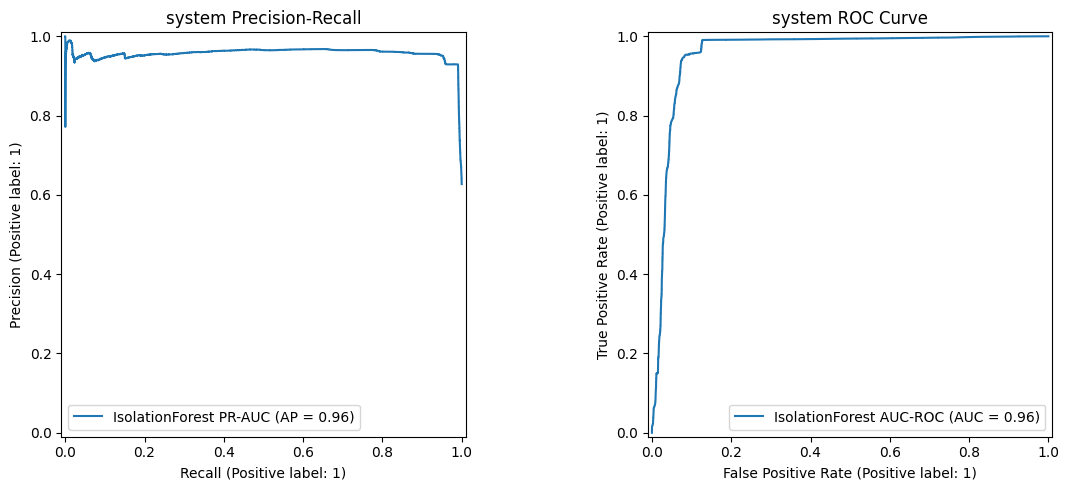

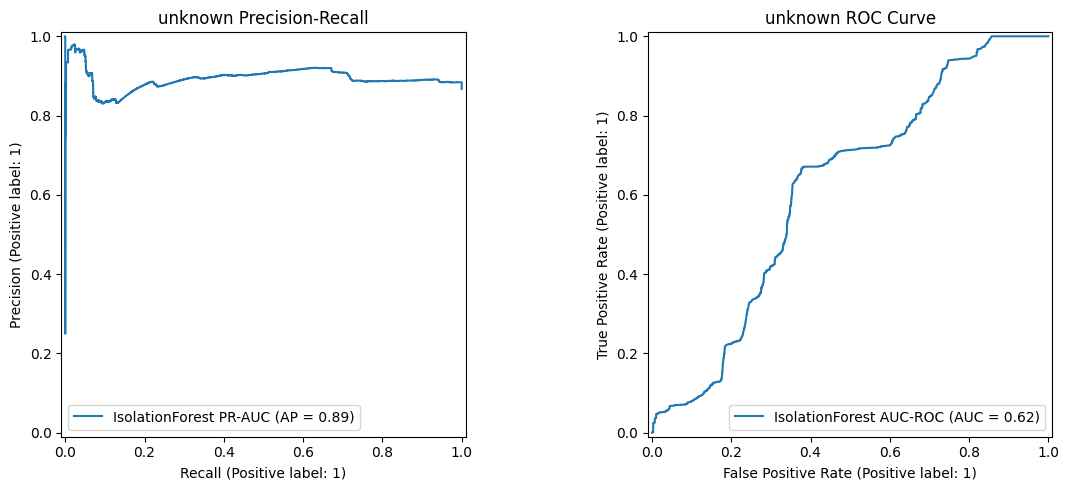

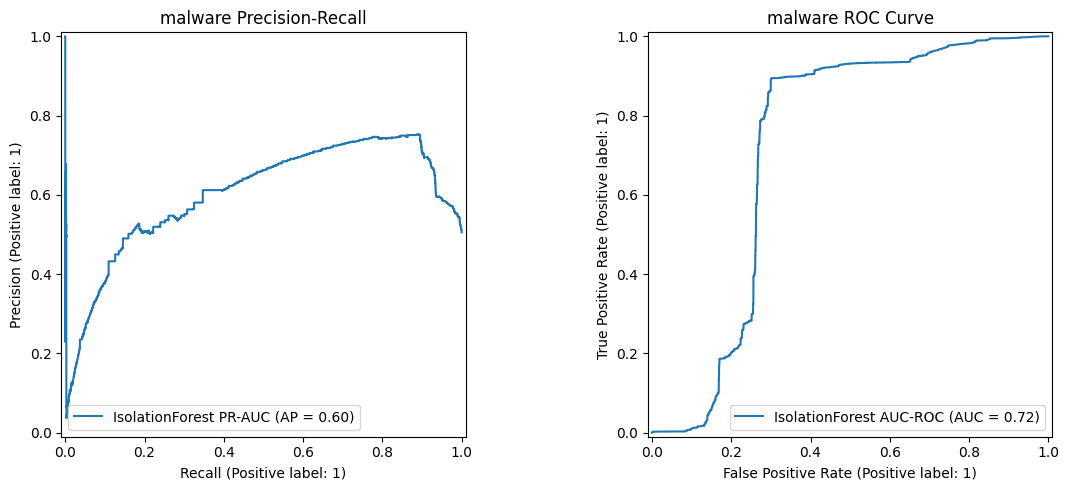

In [17]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay, average_precision_score
from tls_profiling.preprocessing import extract_features, build_and_fit_preprocessor 

import warnings

warnings.filterwarnings(
    "ignore",
    message=r"unknown class\(es\) .* will be ignored",
    category=UserWarning,
    module=r"sklearn\.preprocessing\._label",
)


def plot_curves(normal_label):
    y_true = df_test["connection_label"] != normal_label
    df_train_normal = (df_train[df_train["connection_label"] == normal_label].reset_index(drop=True))

    # fit preprocessors that learns the categorical features encoding
    preprocessor=build_and_fit_preprocessor(extract_features(df_train))
    # create detectyor for malware:
    detector = train_detector(preprocessor.transform(extract_features(df_train_normal)))
    anomaly_score = detector.score(preprocessor.transform(extract_features(df_test)))

    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    PrecisionRecallDisplay.from_predictions(
        y_true,
        anomaly_score,
        name="IsolationForest PR-AUC",
        ax=axes[0],
    )
    axes[0].set_title(f"{normal_label} Precision-Recall")

    RocCurveDisplay.from_predictions(
        y_true,
        anomaly_score,
        name="IsolationForest AUC-ROC",
        ax=axes[1],
    )
    axes[1].set_title(f"{normal_label} ROC Curve")

    plt.tight_layout()
    plt.show()

for l in ["system", "unknown", "malware"]:
    plot_curves(l)
